In [2]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Leitura do Dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()

In [3]:
# Separação das colunas do Dataset entre categoricas e numéricas

# colunas categoricas
colunas_categoricas = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International',
    'Target'
]

# colunas numericas
colunas_numericas = [
    'Previous qualification (grade)',                      
    'Admission grade',                                      
    'Age at enrollment',                                   
    'Curricular units 1st sem (credited)',                  
    'Curricular units 1st sem (enrolled)',                  
    'Curricular units 1st sem (evaluations)',               
    'Curricular units 1st sem (approved)',                  
    'Curricular units 1st sem (grade)',                     
    'Curricular units 1st sem (without evaluations)',       
    'Curricular units 2nd sem (credited)',                  
    'Curricular units 2nd sem (enrolled)',                  
    'Curricular units 2nd sem (evaluations)',               
    'Curricular units 2nd sem (approved)',                  
    'Curricular units 2nd sem (grade)',                     
    'Curricular units 2nd sem (without evaluations)',       
    'Unemployment rate',                                    
    'Inflation rate',                                       
    'GDP'                                                  
]

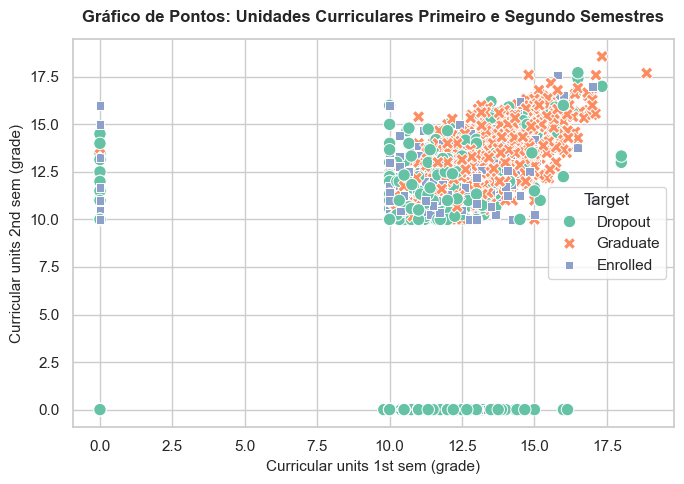

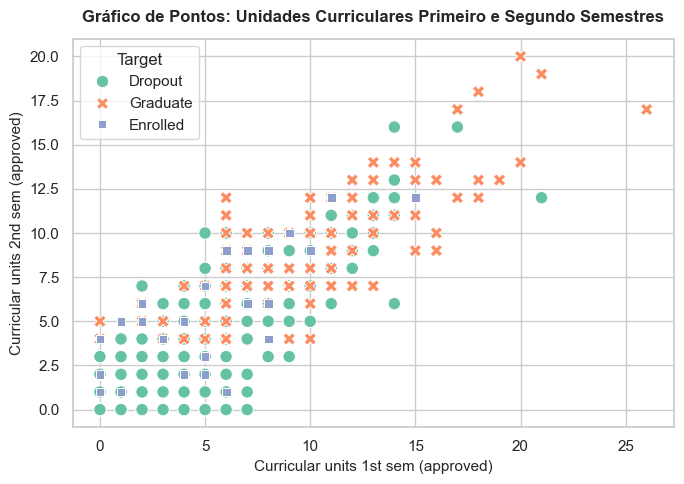

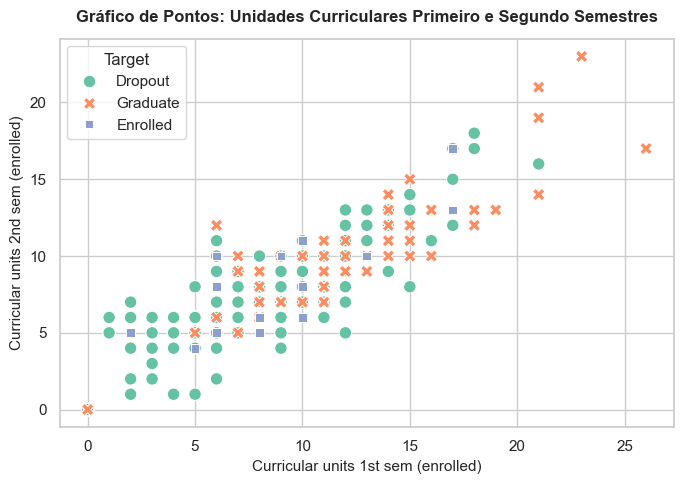

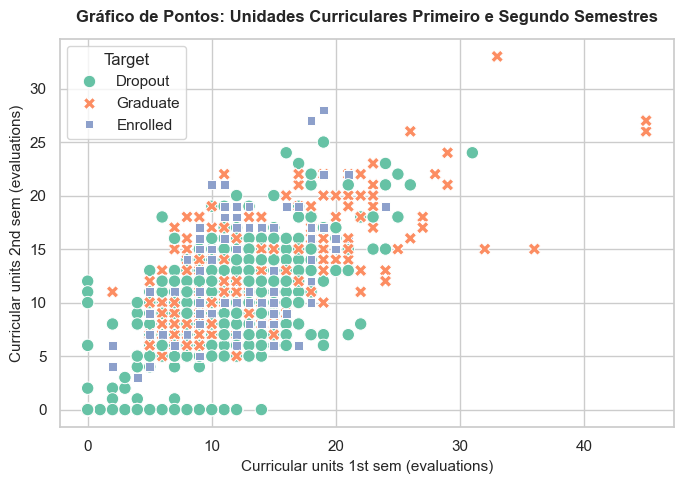

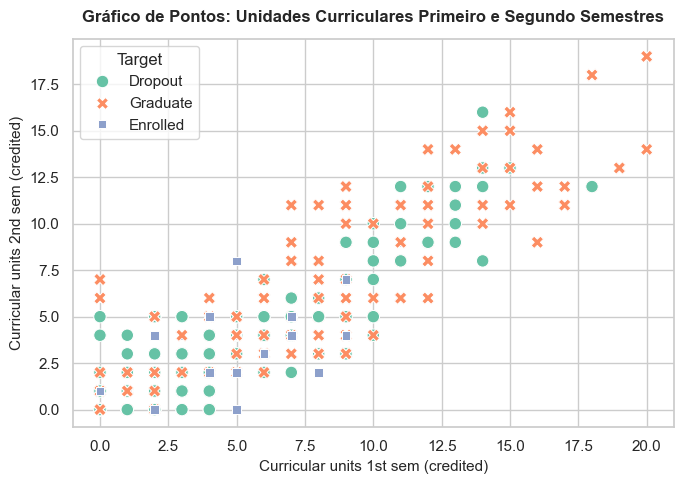

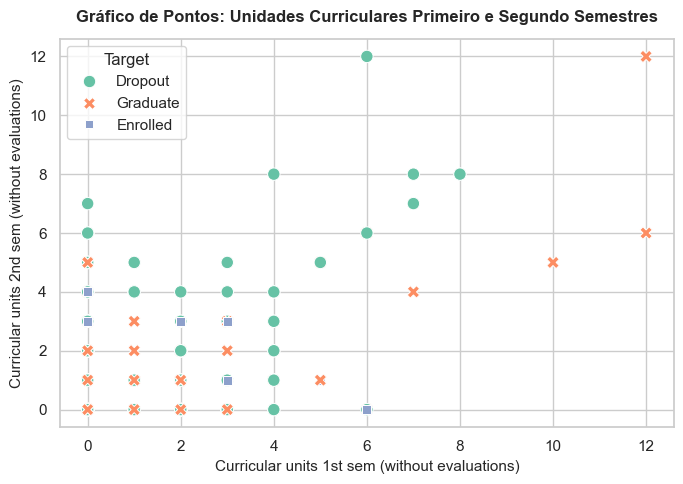

In [11]:
# Gráficos de dispersão por pares relacionados as variáveis de Unidades Curriculares dos Semestres
sns.set_theme(style="whitegrid")
pares_de_variaveis = [
    ('Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)'),
    ('Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)'),
    ('Curricular units 1st sem (enrolled)', 'Curricular units 2nd sem (enrolled)'),
    ('Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (evaluations)'),
    ('Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)'),
    ('Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (without evaluations)')
]

for coluna_x, coluna_y in pares_de_variaveis:

    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=students_df,
        x=coluna_x,
        y=coluna_y,
        hue='Target',          
        palette='Set2',        
        alpha=1,             
        style='Target',        
        s=80
    )

    plt.title(f'Gráfico de Pontos: Unidades Curriculares Primeiro e Segundo Semestres', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(coluna_x, fontsize=11)
    plt.ylabel(coluna_y, fontsize=11)
    plt.legend(title='Target', loc='best')
    plt.tight_layout()
    plt.show()

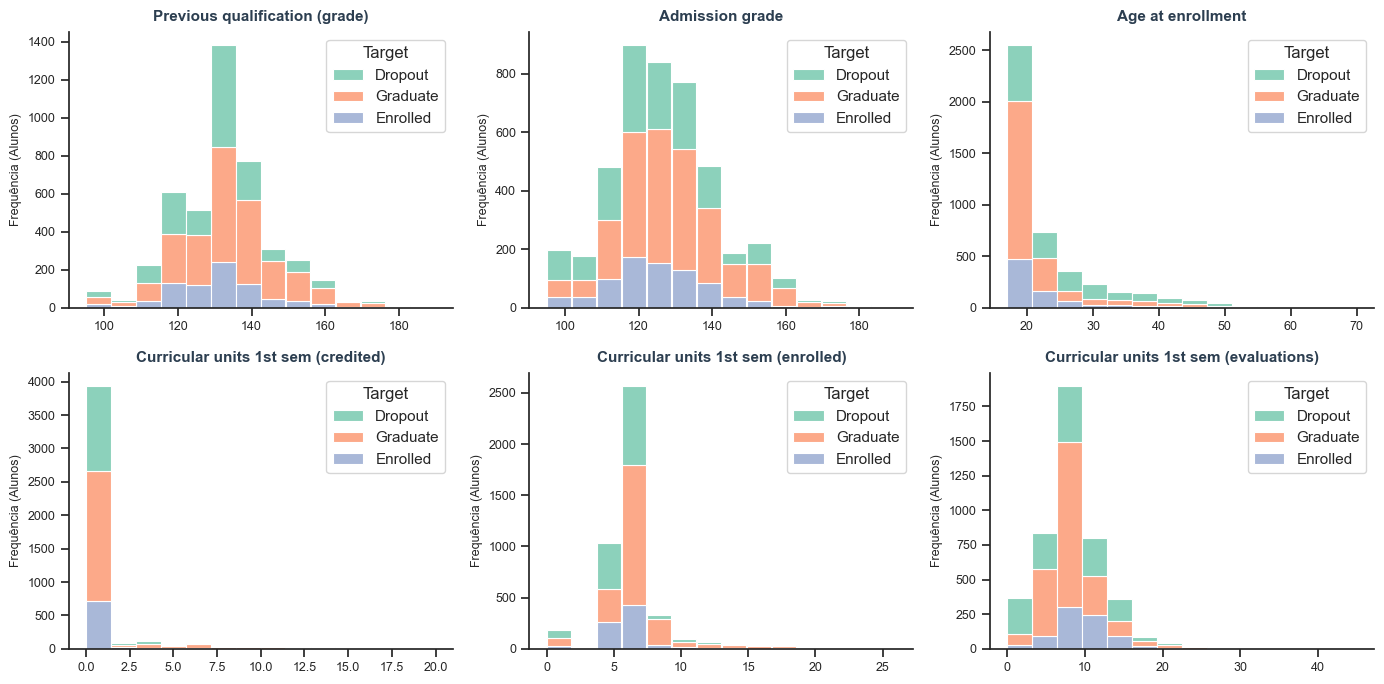

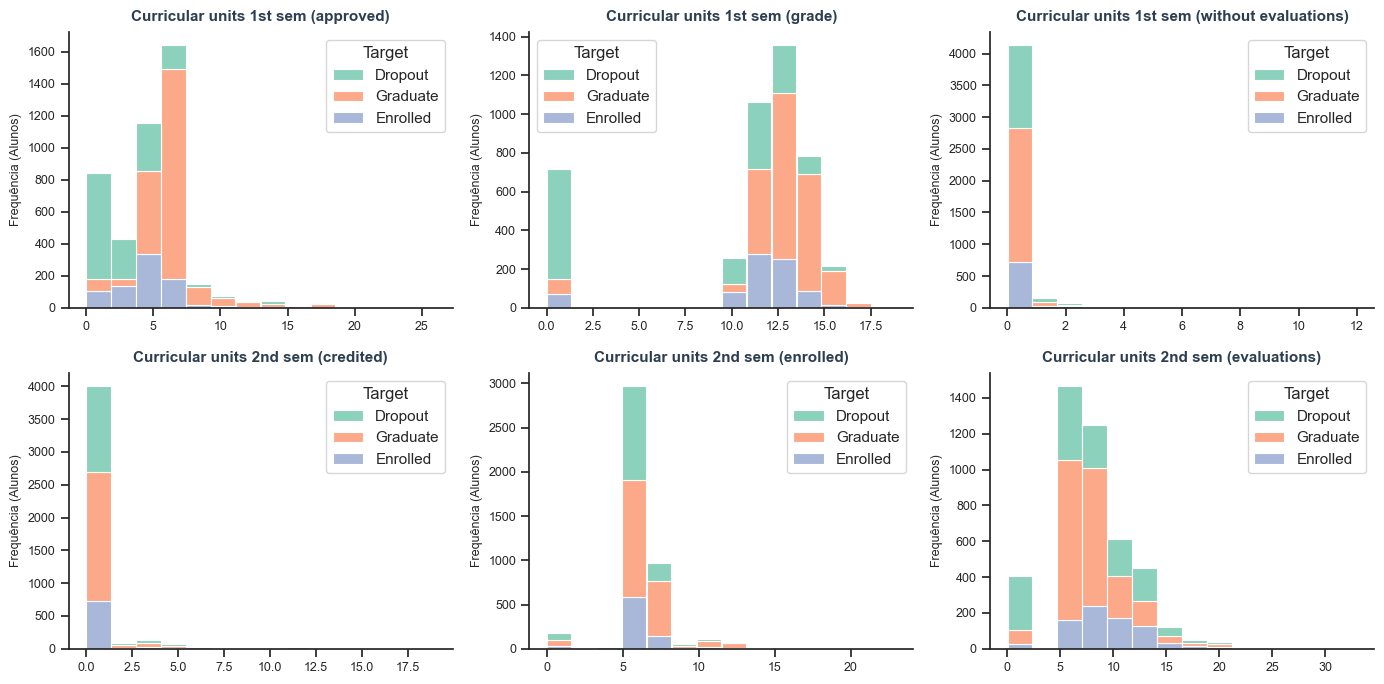

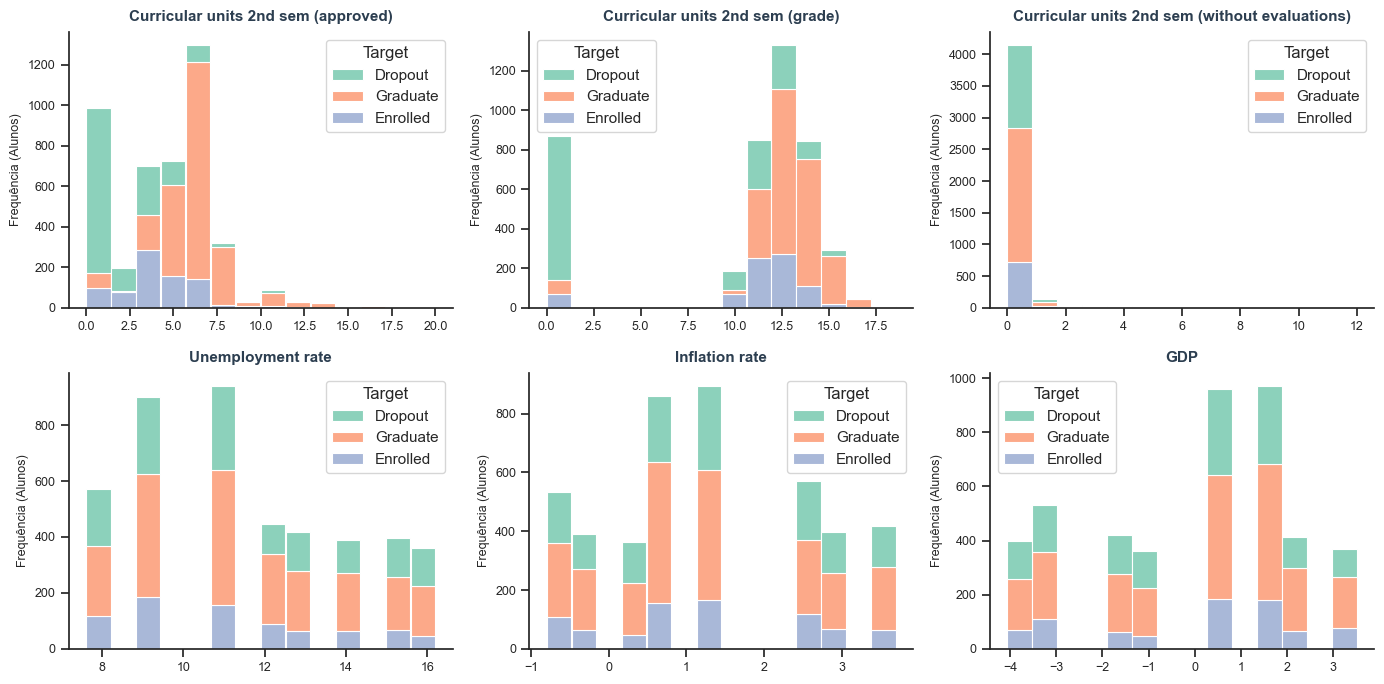

In [16]:
# Histograma de Distribuição de Frequência por Rótulo da classe Target

sns.set_theme(style="ticks") 
graficos_por_janela = 6
colunas_para_processar = colunas_numericas.copy()

while len(colunas_para_processar) > 0:
    bloco_atual = colunas_para_processar[:graficos_por_janela]
    colunas_para_processar = colunas_para_processar[graficos_por_janela:]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten() 
    
    for i, coluna in enumerate(bloco_atual):
        sns.histplot(
            data=students_df, 
            x=coluna, 
            hue='Target',       
            multiple='stack',   
            bins = 14,
            kde=False,          
            discrete=False,     
            shrink=0.98,        
            palette='Set2',     
            edgecolor='white',  
            linewidth=0.8,
            ax=axes[i]          
        )
        
        axes[i].set_title(coluna, fontsize=11, fontweight='bold', pad=8, color='#2c3e50')
        axes[i].set_xlabel('') 
        axes[i].set_ylabel('Frequência (Alunos)', fontsize=9)
        axes[i].tick_params(labelsize=9) 
        
    for j in range(len(bloco_atual), len(axes)):
        fig.delaxes(axes[j])
        
    sns.despine()
    plt.tight_layout()
    plt.show()

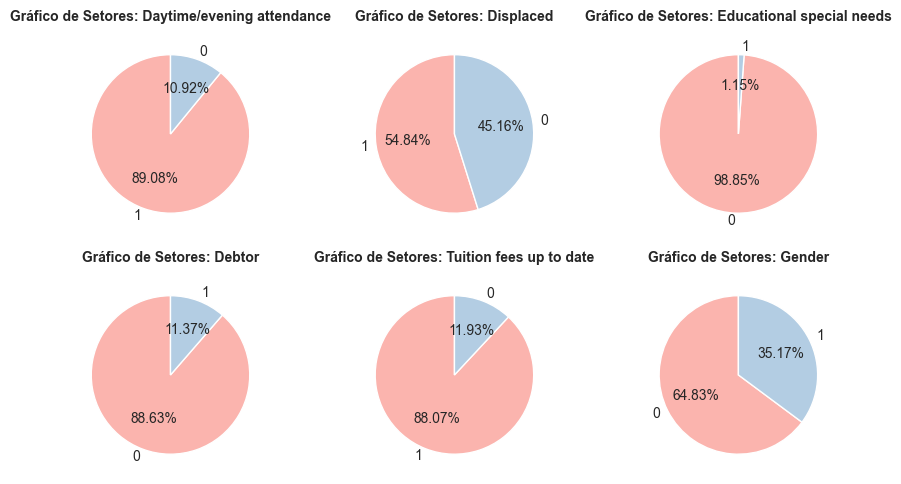

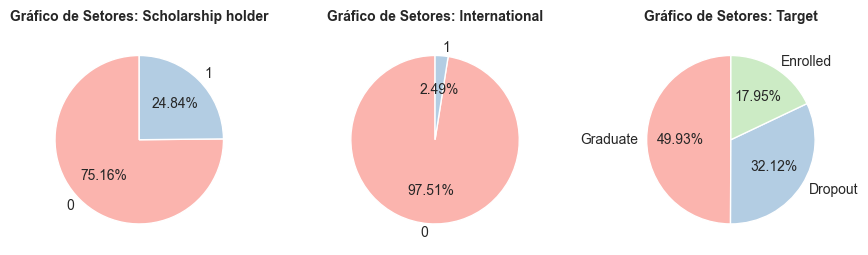

In [22]:
# Gráficos de setores para os atributos categóricos do dataset 
cores = sns.color_palette('Pastel1')
colunas_para_pizza = []

for col in colunas_categoricas:
    quantidade_classes = students_df[col].nunique()
    if quantidade_classes <= 5:
        colunas_para_pizza.append(col)

graficos_por_janela = 6

while len(colunas_para_pizza) > 0:
    bloco_atual = colunas_para_pizza[:graficos_por_janela]
    colunas_para_pizza = colunas_para_pizza[graficos_por_janela:]
    fig, axes = plt.subplots(2, 3, figsize=(9,5))
    axes = axes.flatten()
    
    for i, coluna in enumerate(bloco_atual):
        contagem = students_df[coluna].value_counts()
        
        axes[i].pie(
            contagem, 
            labels=contagem.index, 
            autopct='%1.2f%%',     
            startangle=90,          
            colors=cores,
            textprops={'fontsize': 10} 
        )
        
        axes[i].set_title(f'Gráfico de Setores: {coluna}', fontsize=10, fontweight='bold', pad=10)
    
    for j in range(len(bloco_atual), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

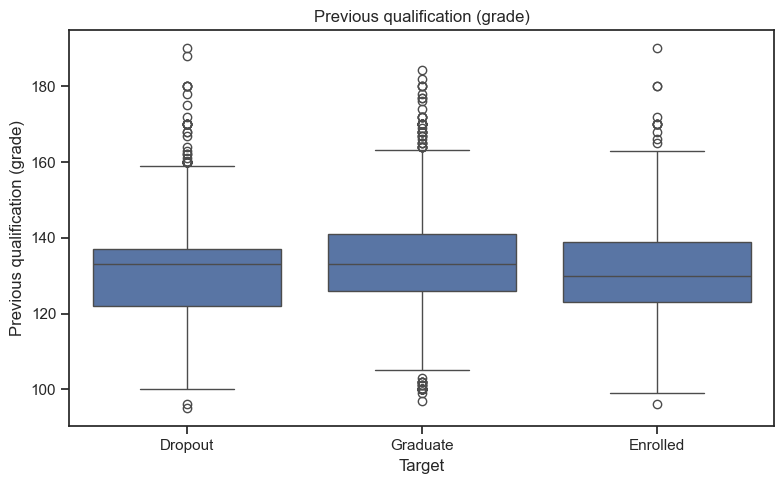

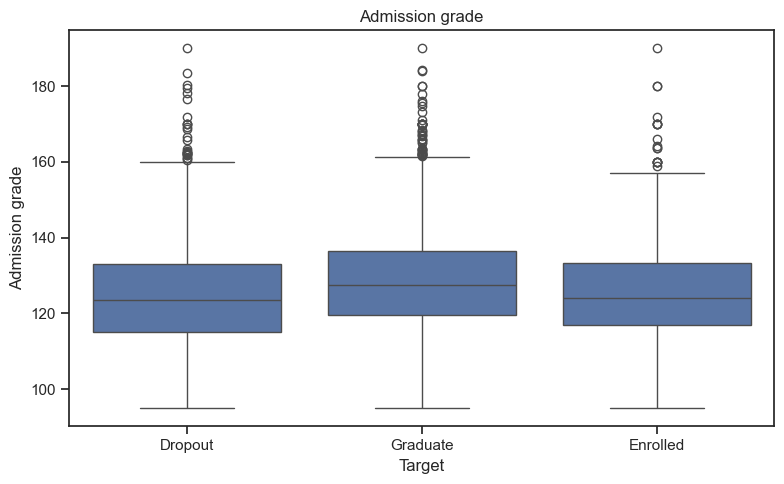

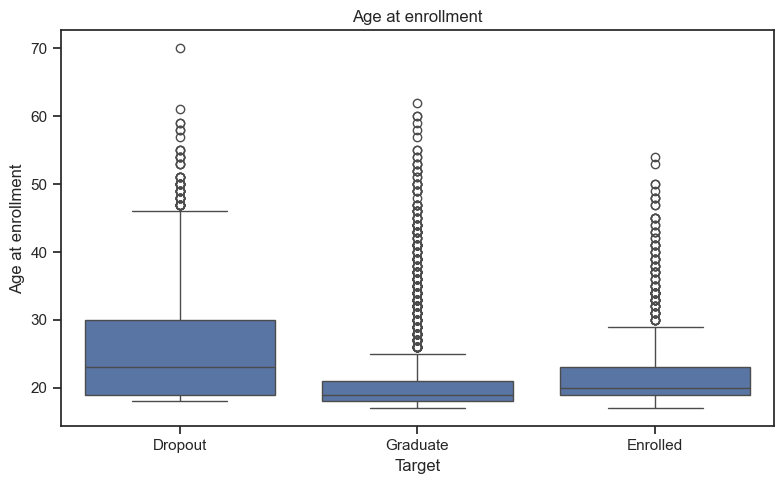

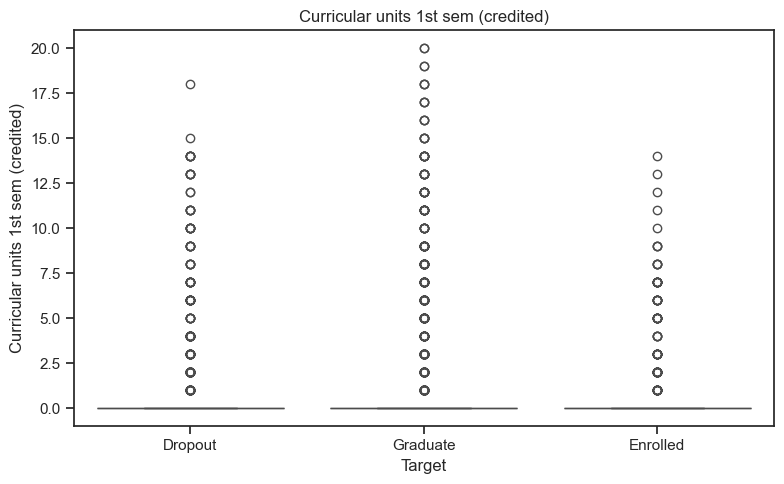

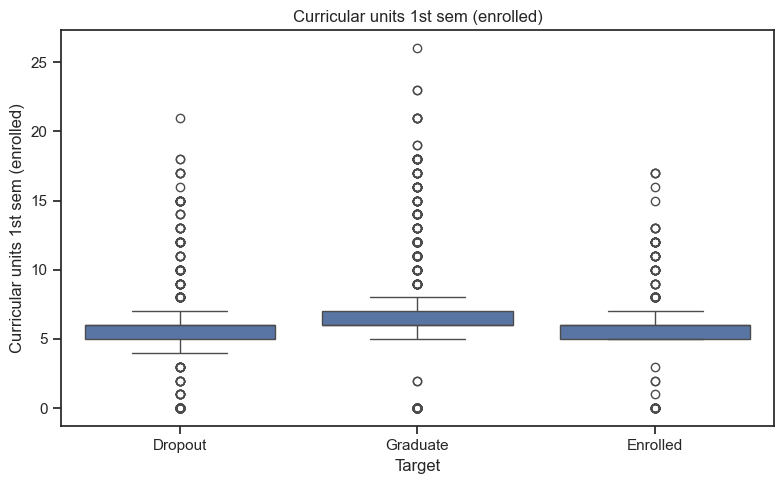

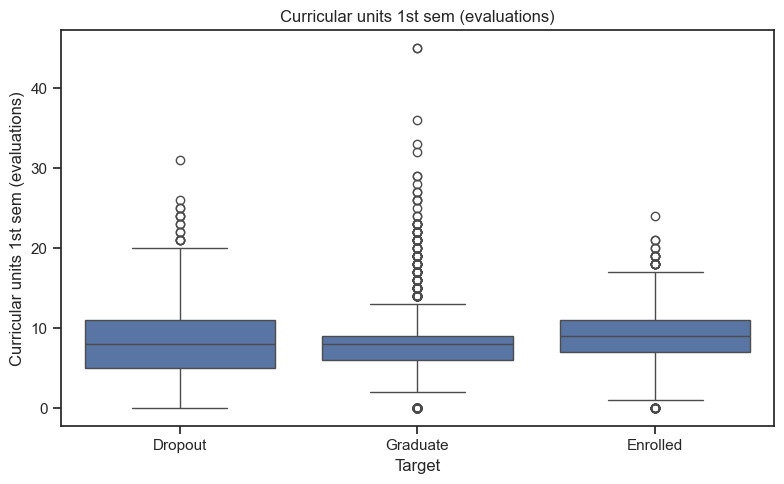

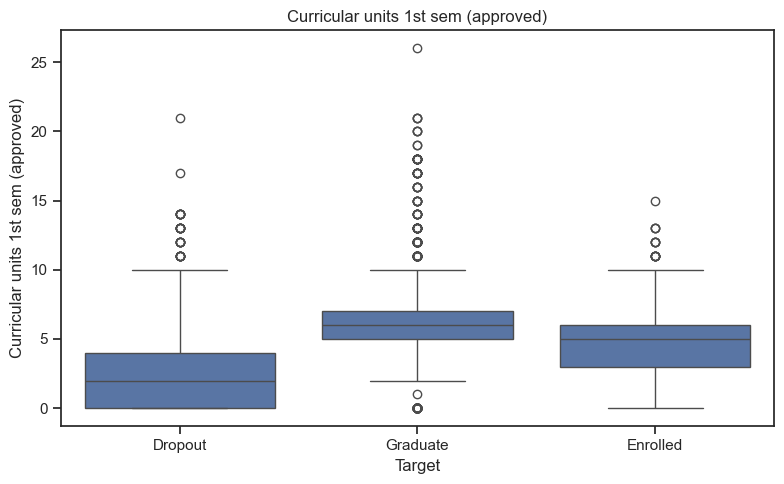

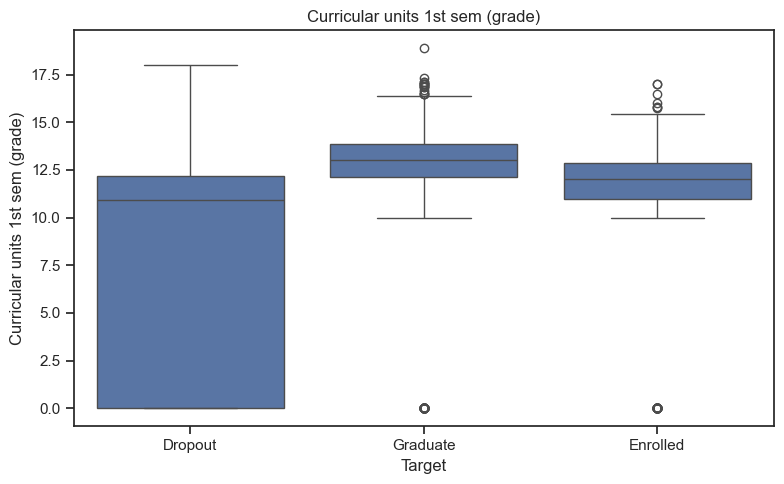

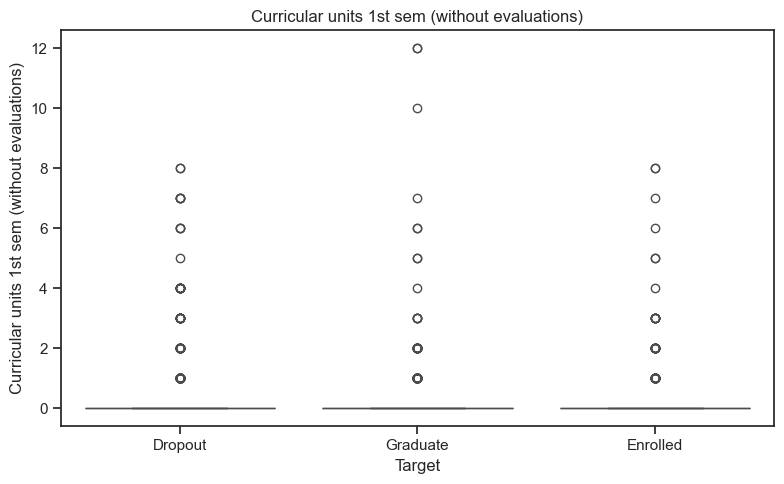

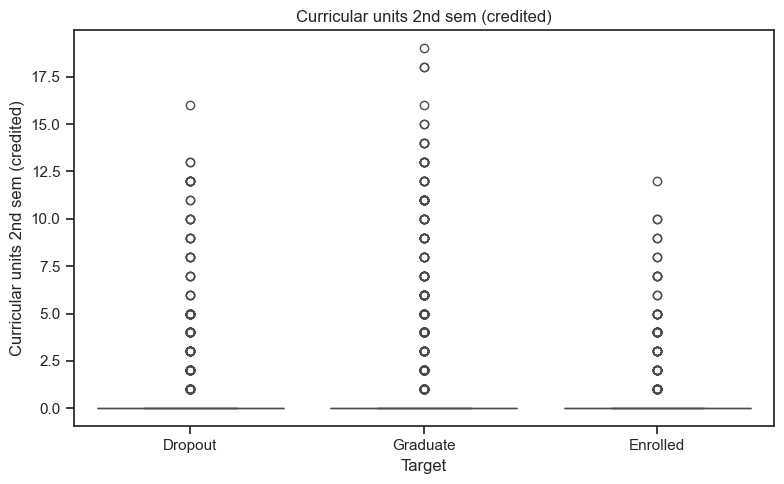

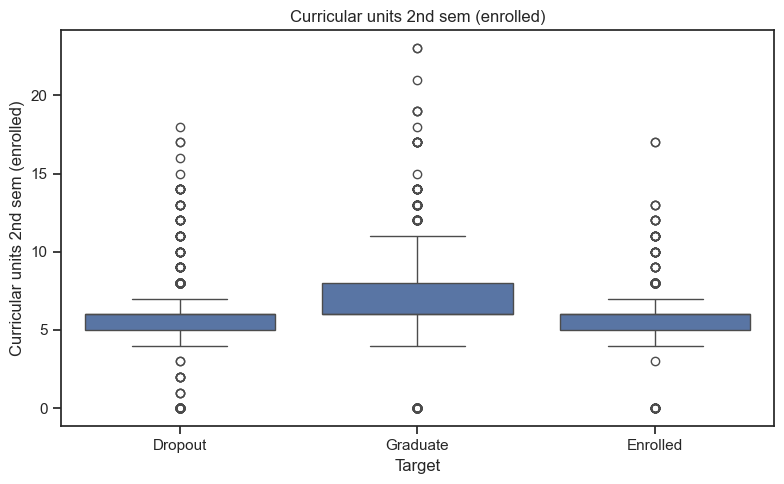

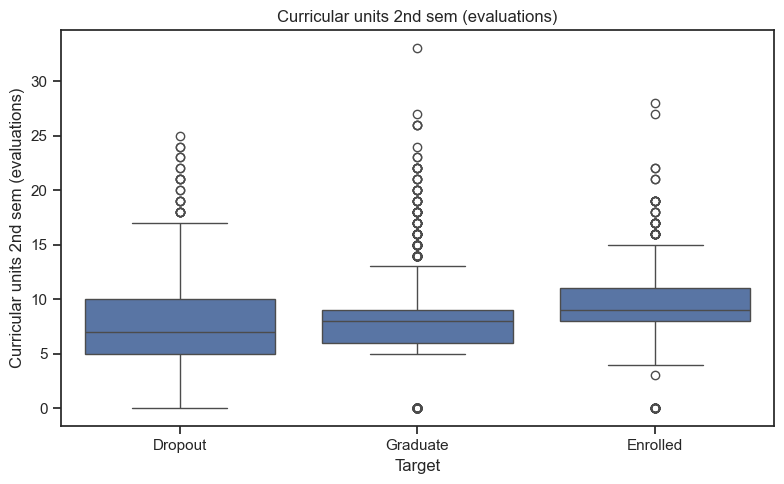

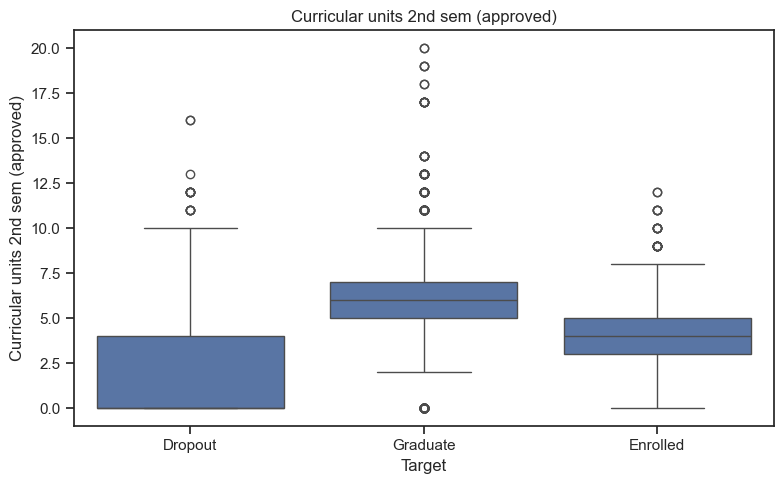

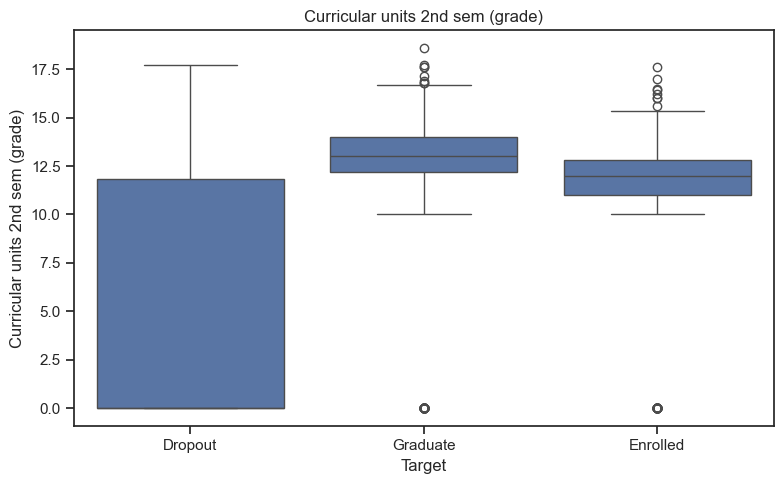

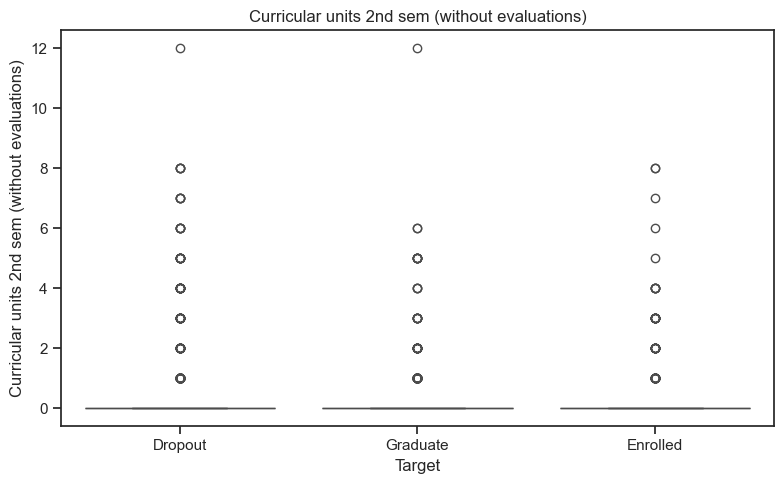

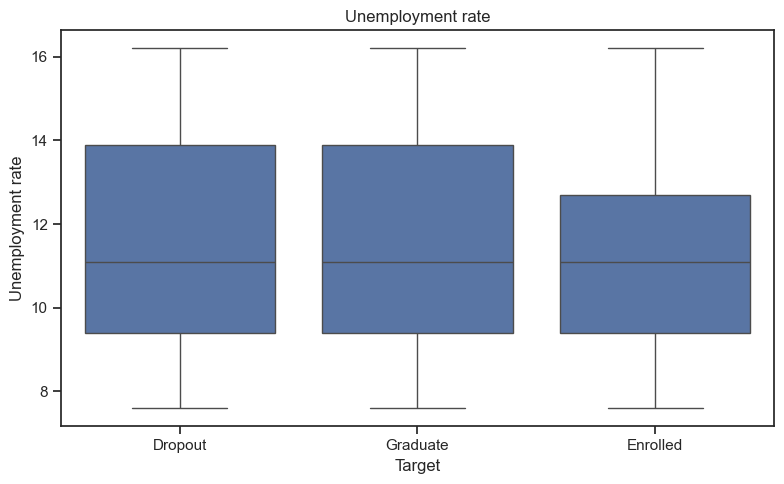

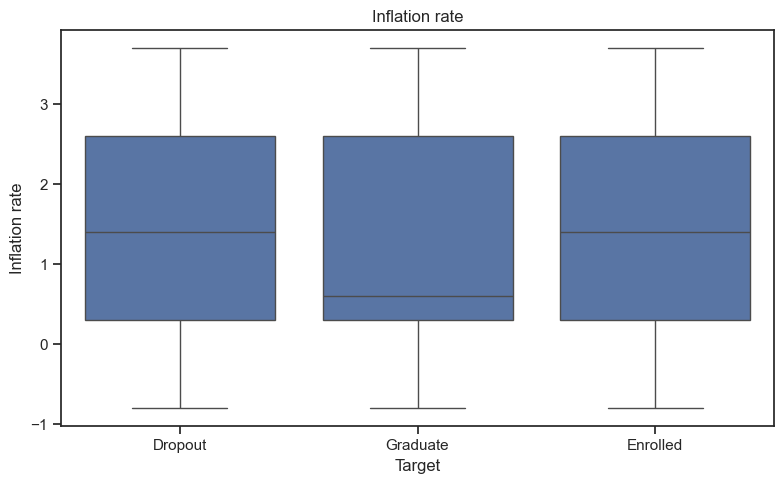

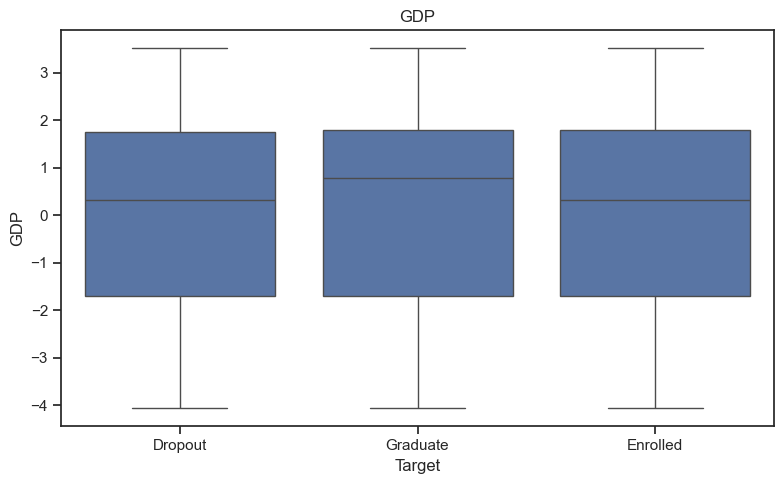

In [23]:
for var in colunas_numericas:
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=students_df,
        x='Target',
        y=var
    )

    plt.title(var)
    plt.show()